# Support Triage Agent — Human-in-the-Loop Reviewer Queue

Reads `outputs/databases/triage.db` and `outputs/databases/threads.db`
directly -- the real, accumulated SQLite state left behind by actual runs of
this app (CLI batch runs, `--queue` runs, and the Streamlit reviewer UI in
`ui/streamlit_app.py`) via `src/persistence/db.py::ReviewStore` and
`src/memory/customer_thread_store.py::CustomerThreadStore`.

Reviewer actions come from `src/hitl/reviewer_actions.py`'s Approve / Reject /
Edit / Escalate / Regenerate set -- what a human reviewer does at the
Streamlit UI's queue tab.

In [1]:
import sys, sqlite3, json
from pathlib import Path

REPO_ROOT = Path.cwd()
while not (REPO_ROOT / "src").is_dir():
    REPO_ROOT = REPO_ROOT.parent
sys.path.insert(0, str(REPO_ROOT))

import pandas as pd
from src.config.settings import get_settings

settings = get_settings()
reviews_conn = sqlite3.connect(settings.reviewer_db_path)
threads_conn = sqlite3.connect(settings.thread_store_path)

reviews = pd.read_sql_query("SELECT * FROM reviews ORDER BY id", reviews_conn)
threads = pd.read_sql_query("SELECT * FROM customer_threads ORDER BY id", threads_conn)
print(f"{settings.reviewer_db_path.relative_to(REPO_ROOT)}: {len(reviews)} review rows")
print(f"{settings.thread_store_path.relative_to(REPO_ROOT)}: {len(threads)} thread rows")

outputs/databases/triage.db: 54 review rows
outputs/databases/threads.db: 22 thread rows


## 1. Status distribution

`status` is `PENDING_REVIEW` for anything the queue-mode graph run left unresolved (what the Streamlit UI's queue tab lists), or the terminal reviewer action once a human has acted on it.

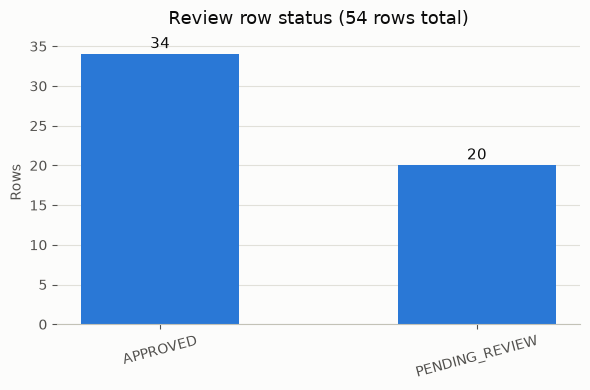

In [2]:
import matplotlib.pyplot as plt

status_counts = reviews["status"].value_counts()

fig, ax = plt.subplots(figsize=(6, 4), facecolor="#fcfcfb")
ax.set_facecolor("#fcfcfb")
bars = ax.bar(status_counts.index, status_counts.values, color="#2a78d6", width=0.5)
for bar, val in zip(bars, status_counts.values):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.3, str(val),
            ha="center", va="bottom", color="#0b0b0b", fontsize=11)
ax.set_title(f"Review row status ({len(reviews)} rows total)", color="#0b0b0b", fontsize=13, pad=12)
ax.set_ylabel("Rows", color="#52514e")
ax.spines[["top", "right", "left"]].set_visible(False)
ax.spines["bottom"].set_color("#c3c2b7")
ax.tick_params(colors="#52514e")
ax.yaxis.grid(True, color="#e1e0d9", linewidth=0.8)
ax.set_axisbelow(True)
plt.xticks(rotation=15)
plt.tight_layout()
plt.show()

## 2. The pending queue

What `ui/streamlit_app.py`'s reviewer queue tab shows right now.

In [3]:
pending = reviews[reviews["status"] == "PENDING_REVIEW"].sort_values("created_at")
pending[["id", "ticket_id", "route_decision", "route_reason", "regenerate_count", "created_at"]].head(15)

,id,ticket_id,route_decision,route_reason,regenerate_count,created_at
2,3,TCK-1003,ESCALATE,refund_outside_window,0,2026-08-15T06:03:45.464413+00:00
3,4,TCK-1004,AUTO_RESOLVE,policy_grounded_response,0,2026-08-15T06:03:46.374826+00:00
4,5,TCK-1005,ASK_INFO,missing_required_fields,0,2026-08-15T06:03:47.514713+00:00
5,6,TCK-1006,ASK_INFO,missing_required_fields,0,2026-08-15T06:03:48.306150+00:00
6,7,TCK-1007,ASK_INFO,classifier_requires_more_info,0,2026-08-15T06:03:49.593976+00:00
7,8,TCK-1008,ESCALATE,refund_outside_window,0,2026-08-15T06:03:50.787326+00:00
8,9,TCK-1009,REFUSE,abusive_content_detected,0,2026-08-15T06:03:51.055441+00:00
9,10,TCK-1010,REFUSE,refund_abuse_language_detected,0,2026-08-15T06:03:51.242561+00:00
10,11,TCK-1011,AUTO_RESOLVE,policy_grounded_response,0,2026-08-15T06:03:52.483882+00:00
11,12,TCK-1012,ASK_INFO,missing_required_fields,0,2026-08-15T06:03:54.678785+00:00


## 3. Approved history

Rows a reviewer (or `--auto-approve`) has already approved, with the confidence scores that were visible at review time.

In [4]:
approved = reviews[reviews["status"] == "APPROVED"].sort_values("created_at", ascending=False)
approved[["id", "ticket_id", "route_decision", "confidence_score", "llm_groundedness_score", "created_at"]].head(15)

,id,ticket_id,route_decision,confidence_score,llm_groundedness_score,created_at
53,54,TCK-1001,ESCALATE,0.593590,0.90,2026-08-15T07:21:11.263811+00:00
52,53,TCK-1001,ESCALATE,0.593590,0.90,2026-08-15T07:20:29.491400+00:00
51,52,TCK-1001,ESCALATE,0.593590,0.95,2026-08-15T07:20:20.836221+00:00
50,51,TCK-1001,ESCALATE,0.593590,0.90,2026-08-15T07:20:12.431947+00:00
49,50,TCK-1001,ESCALATE,0.593590,0.90,2026-08-15T07:19:42.841077+00:00
48,49,TCK-1001,AUTO_RESOLVE,0.556774,1.00,2026-08-15T07:19:28.176533+00:00
47,48,TCK-1022,AUTO_RESOLVE,0.374593,1.00,2026-08-15T07:18:55.608356+00:00
46,47,TCK-1021,REFUSE,0.300249,NaN,2026-08-15T07:18:48.479779+00:00
45,46,TCK-1020,ESCALATE,0.507826,NaN,2026-08-15T07:18:46.090910+00:00
44,45,TCK-1019,AUTO_RESOLVE,0.652414,1.00,2026-08-15T07:18:40.804487+00:00


## 4. Regenerations

`regenerate_count` (set from `ReviewStore.count_for_ticket()` at insert time) counts every prior review row for that ticket, whether it came from re-running the CLI over the same ticket or from a reviewer clicking Regenerate (`src/hitl/reviewer_actions.py::regenerate()`, which also marks the superseded row's `status` accordingly). `TCK-1001` has the deepest history in this database -- 9 rows from repeated real runs during development, most recently landing on `ESCALATE`/`low_confidence_after_retries`.

In [5]:
reviews["regenerate_count"].value_counts().sort_index().to_frame("rows")

,rows
regenerate_count,
0,22
1,22
2,4
3,1
4,1
5,1
6,1
7,1
8,1


In [6]:
most_regenerated = reviews.loc[reviews.groupby("ticket_id")["regenerate_count"].idxmax()]
most_regenerated = most_regenerated.sort_values("regenerate_count", ascending=False)
most_regenerated[["ticket_id", "regenerate_count", "route_decision", "status", "updated_at"]].head(8)

,ticket_id,regenerate_count,route_decision,status,updated_at
53,TCK-1001,8,ESCALATE,APPROVED,2026-08-15T07:21:11.263811+00:00
42,TCK-1017,2,ESCALATE,APPROVED,2026-08-15T07:18:29.500380+00:00
34,TCK-1009,2,REFUSE,APPROVED,2026-08-15T07:17:54.538847+00:00
35,TCK-1010,2,REFUSE,APPROVED,2026-08-15T07:17:55.961700+00:00
38,TCK-1013,1,ASK_INFO,APPROVED,2026-08-15T07:18:11.050353+00:00
46,TCK-1021,1,REFUSE,APPROVED,2026-08-15T07:18:48.479779+00:00
45,TCK-1020,1,ESCALATE,APPROVED,2026-08-15T07:18:46.090910+00:00
44,TCK-1019,1,AUTO_RESOLVE,APPROVED,2026-08-15T07:18:40.804487+00:00


## 5. One full review row, end to end

In [7]:
sample = reviews.iloc[-1]
sample_dict = sample.to_dict()
sample_dict["retrieved_sources"] = json.loads(sample_dict["retrieved_sources"] or "[]")
print(json.dumps(sample_dict, indent=2, default=str))

{
  "id": 54,
  "ticket_id": "TCK-1001",
  "customer_id": "CUST-001",
  "subject": "Refund request for annual plan",
  "message": "I was charged for an annual plan yesterday (order ORD-1002) and would like a refund.",
  "draft_reply": "Draft Reply:\n\nDear Customer,\n\nThank you for reaching out to us about your refund request for order ORD-1002. According to our refund policy [source: refund_policy.md], refund requests are accepted only within 7 days of the original purchase date. Since you were charged yesterday, your request is within the eligible timeframe.\n\nHowever, refunds for annual plans are reviewed case by case and may be denied if the plan was already used for a significant period [source: refund_policy.md]. To process your refund review, we will need to assess your usage of the annual plan.\n\nIf you have any questions or concerns, please let us know and we will be happy to assist you. \n\nBest regards,\nSupport Team",
  "route_decision": "ESCALATE",
  "route_reason": "lo

## 6. Persistent customer conversation threads

`CustomerThreadStore` -- one row per ticket thread. `message_count` reflects `conversation_history` on the source ticket, which is mostly empty in this synthetic dataset (single-turn tickets), so most rows show 0.

In [8]:
print(f"Total threads:      {len(threads)}")
print(f"Unique customers:   {threads['customer_id'].nunique()}")
print(f"Total messages:     {threads['message_count'].sum()}")
threads[["ticket_id", "customer_id", "message_count", "created_at"]].head(10)

Total threads:      22
Unique customers:   22
Total messages:     1


,ticket_id,customer_id,message_count,created_at
0,TCK-1001,CUST-001,0,2026-08-15T06:03:41.311840+00:00
1,TCK-1002,CUST-002,1,2026-08-15T06:03:43.521370+00:00
2,TCK-1003,CUST-003,0,2026-08-15T06:03:44.545258+00:00
3,TCK-1004,CUST-004,0,2026-08-15T06:03:45.468169+00:00
4,TCK-1005,CUST-005,0,2026-08-15T06:03:46.378705+00:00
5,TCK-1006,CUST-006,0,2026-08-15T06:03:47.518669+00:00
6,TCK-1007,CUST-007,0,2026-08-15T06:03:48.309302+00:00
7,TCK-1008,CUST-008,0,2026-08-15T06:03:49.596454+00:00
8,TCK-1009,CUST-009,0,2026-08-15T06:03:50.789934+00:00
9,TCK-1010,CUST-010,0,2026-08-15T06:03:51.058107+00:00


In [9]:
reviews_conn.close()
threads_conn.close()